<a href="https://colab.research.google.com/github/eshwar-7419/cads/blob/main/CARC_IDS_Phase1A_Validation_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1A — Baseline Validation for CARC-IDS/IPS

This notebook uses the **exact dataset source/configuration actually used in Phase 1**:

```python
from datasets import load_dataset

ds = load_dataset("lacg030175/UNSW-NB15", "temporal")
train_df = ds["train"].to_pandas()
test_df  = ds["test"].to_pandas()
```

The dataset card identifies `temporal` as the original UNSW-NB15 temporal split: 175,341 training rows and 82,332 test rows, with temporal separation between train and test. It describes this as the realistic "train on past, test on future" protocol.

This notebook performs the three checks we need before Phase 2:

1. **Dataset integrity / leakage diagnostics**
2. **Original features vs original + behavioral features**
3. **Threshold analysis without tuning on the final test set**
4. Probability calibration diagnostics
5. Final baseline operating-point selection
6. A clean result package for Phase 2

### Important experimental rule

The final test set is **not used to select the operating threshold**. A validation portion is created from the training data and used for threshold selection. The final test set is evaluated once after the operating point is frozen.


In [1]:
# 1. Install dependencies
!pip -q install datasets lightgbm psutil joblib scikit-learn

print("Dependencies installed.")


Dependencies installed.


In [2]:
# 2. Imports and reproducibility
import os, time, json, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import joblib

from datasets import load_dataset

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    brier_score_loss, roc_auc_score, average_precision_score
)
from sklearn.calibration import calibration_curve
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

BASE = Path("/content/carc_ids_phase1a")
RESULTS = BASE / "results"
ARTIFACTS = BASE / "artifacts"
for p in [RESULTS, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE)


Working directory: /content/carc_ids_phase1a


## 3. Load the exact Hugging Face temporal dataset

We deliberately use the `temporal` configuration, not `random`.

The dataset card states that:

- `temporal` is the original temporal split;
- train = 175,341 rows;
- test = 82,332 rows;
- the split has temporal separation;
- binary `label`: 0 = Normal, 1 = Attack.

This is the correct configuration for the planned evolving-threat research.


In [3]:
# 3. Load exact dataset configuration used in Phase 1

ds = load_dataset(
    "lacg030175/UNSW-NB15",
    "temporal"
)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())


README.md:   0%|          | 0.00/5.32k [00:00<?, ?B/s]

temporal/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.7MB            

temporal/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

temporal/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.25MB            

temporal/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/175341 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/82332 [00:00<?, ? examples/s]

Train: (175341, 44)
Test : (82332, 44)

Train columns: ['ackdat', 'attack_cat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'Dintpkt', 'djit', 'dload', 'dloss', 'dmeansz', 'Dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'label', 'proto', 'rate', 'response_body_len', 'sbytes', 'service', 'Sintpkt', 'Sjit', 'sload', 'sloss', 'smeansz', 'Spkts', 'state', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


In [4]:
# 4. Dataset integrity checks

print("Expected approximate sizes from dataset card:")
print("  train: 175,341")
print("  test : 82,332")

print("\nActual sizes:")
print("  train:", len(train_df))
print("  test :", len(test_df))

print("\nLabel distribution — TRAIN")
display(train_df["label"].value_counts(dropna=False).rename("count").to_frame())

print("\nLabel distribution — TEST")
display(test_df["label"].value_counts(dropna=False).rename("count").to_frame())

if "attack_cat" in train_df.columns:
    print("\nAttack categories — TRAIN")
    display(train_df["attack_cat"].value_counts(dropna=False).rename("count").to_frame())


Expected approximate sizes from dataset card:
  train: 175,341
  test : 82,332

Actual sizes:
  train: 175341
  test : 82332

Label distribution — TRAIN


,count
label,
1,119341
0,56000



Label distribution — TEST


,count
label,
1,45332
0,37000



Attack categories — TRAIN


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


In [5]:
# 5. Duplicate and train/test overlap diagnostics

# Exact row duplicates within each split
train_dupes = int(train_df.duplicated().sum())
test_dupes = int(test_df.duplicated().sum())

print("Exact duplicate rows:")
print("  train:", train_dupes)
print("  test :", test_dupes)

# Compare feature tuples excluding label/category for exact cross-split overlap.
# This is a diagnostic, not a proof that all near-duplicates are absent.
overlap_cols = [c for c in train_df.columns if c not in ["label", "attack_cat"]]

train_keys = pd.util.hash_pandas_object(train_df[overlap_cols], index=False)
test_keys = pd.util.hash_pandas_object(test_df[overlap_cols], index=False)

overlap_hashes = len(set(train_keys.astype("uint64")).intersection(set(test_keys.astype("uint64"))))

print("\nExact hashed feature-row overlap across train/test:", overlap_hashes)

print("\nColumn sets identical:", set(train_df.columns) == set(test_df.columns))


Exact duplicate rows:
  train: 67601
  test : 26387

Exact hashed feature-row overlap across train/test: 1302

Column sets identical: True


## 6. Build a leakage-safe feature table

We remove:

- `label` — target;
- `attack_cat` — target-derived multiclass label;
- `id`/index-like identifiers if present.

We keep the network-flow features.

The dataset card states that the temporal configuration contains 44 features excluding `id`, including flow, content, time and additional generated features.


In [6]:
# 6. Prepare target and base features

TARGET = "label"

y_all = train_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()

DROP = [c for c in ["label", "attack_cat", "id", "ID", "index"] if c in train_df.columns]

X_all_raw = train_df.drop(columns=DROP, errors="ignore").copy()
X_test_raw = test_df.drop(columns=DROP, errors="ignore").copy()

print("Dropped:", DROP)
print("Base train shape:", X_all_raw.shape)
print("Base test shape :", X_test_raw.shape)


Dropped: ['label', 'attack_cat']
Base train shape: (175341, 42)
Base test shape : (82332, 42)


In [7]:
# 7. Behavioral feature engineering

def add_behavioral_features(df):
    out = df.copy()
    eps = 1e-6

    def num(col):
        if col in out.columns:
            return pd.to_numeric(out[col], errors="coerce").fillna(0.0)
        return pd.Series(0.0, index=out.index)

    dur = num("dur")
    spkts = num("Spkts")
    dpkts = num("Dpkts")
    sbytes = num("sbytes")
    dbytes = num("dbytes")

    total_packets = spkts + dpkts
    total_bytes = sbytes + dbytes

    out["beh_total_packets"] = total_packets
    out["beh_total_bytes"] = total_bytes
    out["beh_packets_per_sec"] = total_packets / (dur + eps)
    out["beh_bytes_per_sec"] = total_bytes / (dur + eps)
    out["beh_avg_packet_size"] = total_bytes / (total_packets + eps)
    out["beh_fwd_bwd_packet_ratio"] = (spkts + 1.0) / (dpkts + 1.0)
    out["beh_fwd_bwd_byte_ratio"] = (sbytes + 1.0) / (dbytes + 1.0)

    # These are intentionally simple behavioral descriptors.
    # They are not claimed to be novel.
    return out

X_all_fe = add_behavioral_features(X_all_raw)
X_test_fe = add_behavioral_features(X_test_raw)
X_test_fe = X_test_fe.reindex(columns=X_all_fe.columns)

behavioral_cols = [c for c in X_all_fe.columns if c not in X_all_raw.columns]

print("Original features:", len(X_all_raw.columns))
print("After engineering:", len(X_all_fe.columns))
print("Added:", behavioral_cols)


Original features: 42
After engineering: 49
Added: ['beh_total_packets', 'beh_total_bytes', 'beh_packets_per_sec', 'beh_bytes_per_sec', 'beh_avg_packet_size', 'beh_fwd_bwd_packet_ratio', 'beh_fwd_bwd_byte_ratio']


## 8. Temporal validation split

We need a validation set for threshold/model-selection decisions without touching the final test set.

Because this research is explicitly about temporal deployment, we use the **last 20% of the supplied training sequence as validation** and the first 80% as model-development training.

This assumes the row order supplied by the temporal configuration is the appropriate sequence order. We record this assumption explicitly rather than silently treating the split as random.

The final test set remains untouched until the end.


In [8]:
# 8. Development/validation split
split_idx = int(len(X_all_fe) * 0.80)

X_dev_fe = X_all_fe.iloc[:split_idx].copy()
X_val_fe = X_all_fe.iloc[split_idx:].copy()

y_dev = y_all[:split_idx]
y_val = y_all[split_idx:]

print("Development:", X_dev_fe.shape, "labels:", np.bincount(y_dev))
print("Validation :", X_val_fe.shape, "labels:", np.bincount(y_val))
print("Final test :", X_test_fe.shape, "labels:", np.bincount(y_test))


Development: (140272, 49) labels: [56000 84272]
Validation : (35069, 49) labels: [    0 35069]
Final test : (82332, 49) labels: [37000 45332]


In [9]:
# 9. Preprocessing helper

def make_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ])
    return pre

def preprocess_fit_transform(X_fit, X_apply, X_test):
    pre = make_preprocessor(X_fit)
    Xf = pre.fit_transform(X_fit).astype(np.float32)
    Xa = pre.transform(X_apply).astype(np.float32)
    Xt = pre.transform(X_test).astype(np.float32)
    return pre, Xf, Xa, Xt


# 10. Experiment A — Original features vs Original + Behavioral features

We train two otherwise identical LightGBM models:

- **A: Original features only**
- **B: Original + behavioral features**

The purpose is not to cherry-pick the better result. It is to determine whether our feature engineering adds measurable value before continual learning.


In [10]:
# 10A. Original-feature experiment

X_dev_orig = X_dev_fe.drop(columns=behavioral_cols, errors="ignore")
X_val_orig = X_val_fe.drop(columns=behavioral_cols, errors="ignore")
X_test_orig = X_test_fe.drop(columns=behavioral_cols, errors="ignore")

pre_orig, X_dev_o, X_val_o, X_test_o = preprocess_fit_transform(
    X_dev_orig, X_val_orig, X_test_orig
)

model_orig = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

t0 = time.perf_counter()
model_orig.fit(X_dev_o, y_dev)
train_time_orig = time.perf_counter() - t0

p_val_orig = model_orig.predict_proba(X_val_o)[:, 1]
p_test_orig = model_orig.predict_proba(X_test_o)[:, 1]

print("Original-feature model trained.")
print("Processed feature count:", X_dev_o.shape[1])
print("Training time:", round(train_time_orig, 3), "sec")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Original-feature model trained.
Processed feature count: 194
Training time: 9.928 sec


In [11]:
# 10B. Original + behavioral features

pre_fe, X_dev_f, X_val_f, X_test_f = preprocess_fit_transform(
    X_dev_fe, X_val_fe, X_test_fe
)

model_fe = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

t0 = time.perf_counter()
model_fe.fit(X_dev_f, y_dev)
train_time_fe = time.perf_counter() - t0

p_val_fe = model_fe.predict_proba(X_val_f)[:, 1]
p_test_fe = model_fe.predict_proba(X_test_f)[:, 1]

print("Feature-engineered model trained.")
print("Processed feature count:", X_dev_f.shape[1])
print("Training time:", round(train_time_fe, 3), "sec")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Feature-engineered model trained.
Processed feature count: 201
Training time: 10.449 sec


In [12]:
# 11. Threshold-independent validation metrics

def prob_metrics(y, p):
    return {
        "ROC_AUC": roc_auc_score(y, p),
        "PR_AUC": average_precision_score(y, p),
        "Brier": brier_score_loss(y, p)
    }

validation_prob_results = pd.DataFrame([
    {"model": "Original", **prob_metrics(y_val, p_val_orig)},
    {"model": "Original+Behavioral", **prob_metrics(y_val, p_val_fe)}
])

display(validation_prob_results.round(6))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,model,ROC_AUC,PR_AUC,Brier
0,Original,NaN,1.0,0.008040
1,Original+Behavioral,NaN,1.0,0.007962


In [13]:
# 12. Threshold sweep on VALIDATION ONLY

thresholds = np.arange(0.05, 0.951, 0.05)

def threshold_table(y, p, name):
    rows = []
    for t in thresholds:
        pred = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()

        rows.append({
            "model": name,
            "threshold": round(float(t), 2),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "fpr": fp / (fp + tn) if (fp + tn) else 0.0,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn
        })
    return pd.DataFrame(rows)

thr_orig = threshold_table(y_val, p_val_orig, "Original")
thr_fe = threshold_table(y_val, p_val_fe, "Original+Behavioral")
thr_all = pd.concat([thr_orig, thr_fe], ignore_index=True)

display(thr_all.head(10))


,model,threshold,precision,recall,f1,fpr,tp,fp,tn,fn
0,Original,0.05,1.0,1.000000,1.000000,0.0,35069,0,0,0
1,Original,0.10,1.0,1.000000,1.000000,0.0,35069,0,0,0
2,Original,0.15,1.0,0.999914,0.999957,0.0,35066,0,0,3
3,Original,0.20,1.0,0.999800,0.999900,0.0,35062,0,0,7
4,Original,0.25,1.0,0.999059,0.999529,0.0,35036,0,0,33
5,Original,0.30,1.0,0.997776,0.998887,0.0,34991,0,0,78
6,Original,0.35,1.0,0.996493,0.998243,0.0,34946,0,0,123
7,Original,0.40,1.0,0.994097,0.997040,0.0,34862,0,0,207
8,Original,0.45,1.0,0.991559,0.995762,0.0,34773,0,0,296
9,Original,0.50,1.0,0.988337,0.994134,0.0,34660,0,0,409


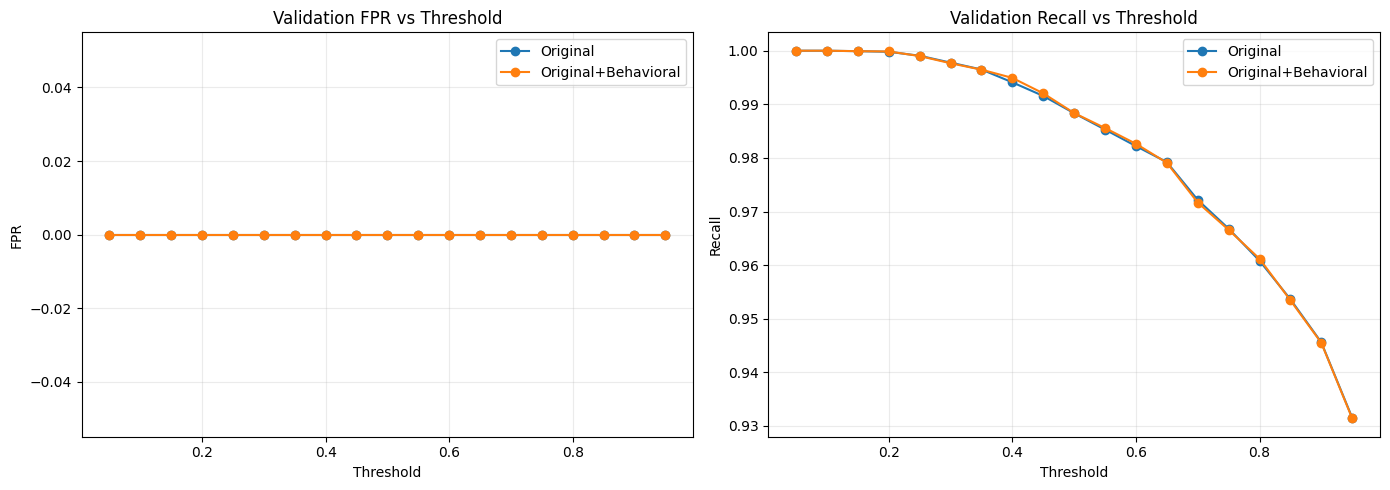

In [14]:
# 13. Plot validation trade-offs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, g in thr_all.groupby("model"):
    axes[0].plot(g["threshold"], g["fpr"], marker="o", label=name)
    axes[1].plot(g["threshold"], g["recall"], marker="o", label=name)

axes[0].set_title("Validation FPR vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("FPR")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("Validation Recall vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Recall")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## 14. Choose an operating threshold without using the final test set

For an IDS/IPS, maximizing F1 alone can produce an operationally poor false-positive rate.

Therefore we report **two threshold-selection views**:

1. **F1-optimal threshold** on validation.
2. **Constrained threshold**: the highest recall threshold among those meeting a predefined FPR budget.

The FPR budget is a research operating constraint, not a claim that one value is universally correct.

We start with **10% validation FPR** as a diagnostic budget. Later, the IPS study can vary this budget.


In [15]:
# 14. Select thresholds on validation only

FPR_BUDGET = 0.10

def choose_f1_threshold(g):
    idx = g["f1"].idxmax()
    return g.loc[idx]

def choose_constrained_threshold(g, fpr_budget=0.10):
    feasible = g[g["fpr"] <= fpr_budget].copy()
    if feasible.empty:
        return None
    # Maximize recall; if tied, prefer higher precision then higher threshold.
    feasible = feasible.sort_values(
        ["recall", "precision", "threshold"],
        ascending=[False, False, False]
    )
    return feasible.iloc[0]

selection_rows = []

for name, g in thr_all.groupby("model"):
    f1_row = choose_f1_threshold(g)
    c_row = choose_constrained_threshold(g, FPR_BUDGET)

    selection_rows.append({
        "model": name,
        "f1_opt_threshold": f1_row["threshold"],
        "f1_opt_f1": f1_row["f1"],
        "f1_opt_recall": f1_row["recall"],
        "f1_opt_fpr": f1_row["fpr"],
        "constrained_threshold": None if c_row is None else c_row["threshold"],
        "constrained_recall": None if c_row is None else c_row["recall"],
        "constrained_precision": None if c_row is None else c_row["precision"],
        "constrained_f1": None if c_row is None else c_row["f1"],
        "constrained_fpr": None if c_row is None else c_row["fpr"]
    })

selection_df = pd.DataFrame(selection_rows)
display(selection_df.round(6))


,model,f1_opt_threshold,f1_opt_f1,f1_opt_recall,f1_opt_fpr,constrained_threshold,constrained_recall,constrained_precision,constrained_f1,constrained_fpr
0,Original,0.05,1.0,1.0,0.0,0.1,1.0,1.0,1.0,0.0
1,Original+Behavioral,0.05,1.0,1.0,0.0,0.1,1.0,1.0,1.0,0.0


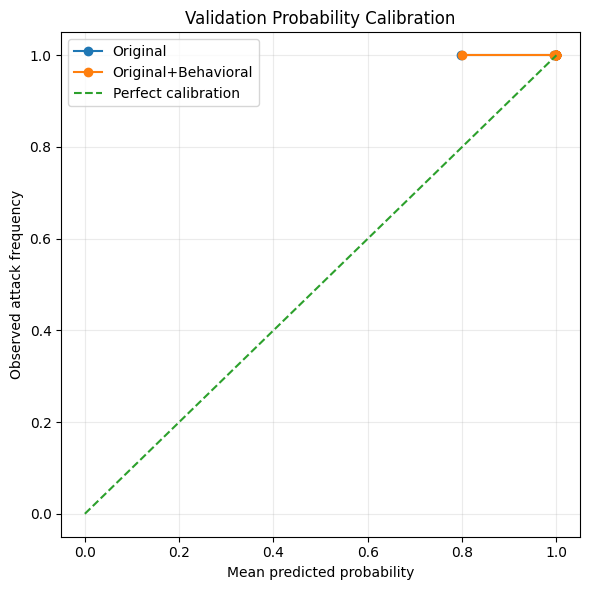

In [16]:
# 15. Calibration diagnostics on VALIDATION ONLY

fig, ax = plt.subplots(figsize=(6, 6))

for name, y, p in [
    ("Original", y_val, p_val_orig),
    ("Original+Behavioral", y_val, p_val_fe)
]:
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed attack frequency")
ax.set_title("Validation Probability Calibration")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 16. Final test evaluation

The model family and operating threshold are now frozen using the development/validation data.

The final test set is evaluated once.

This is the number we should report as the Phase-1A baseline—not the threshold selected by looking at test performance.


In [17]:
# 16. Freeze the better feature set based on validation F1 / constrained operation

# Select the feature set with the better validation F1 at the F1-optimal threshold.
best_feature_set = selection_df.loc[
    selection_df["f1_opt_f1"].idxmax(), "model"
]

print("Selected feature set from validation:", best_feature_set)

if best_feature_set == "Original+Behavioral":
    chosen_model = model_fe
    chosen_test_prob = p_test_fe
    chosen_val_prob = p_val_fe
    chosen_threshold = float(
        selection_df.loc[
            selection_df["model"] == best_feature_set,
            "constrained_threshold"
        ].iloc[0]
    )
    if np.isnan(chosen_threshold):
        chosen_threshold = float(
            selection_df.loc[
                selection_df["model"] == best_feature_set,
                "f1_opt_threshold"
            ].iloc[0]
        )
else:
    chosen_model = model_orig
    chosen_test_prob = p_test_orig
    chosen_val_prob = p_val_orig
    chosen_threshold = float(
        selection_df.loc[
            selection_df["model"] == best_feature_set,
            "constrained_threshold"
        ].iloc[0]
    )
    if np.isnan(chosen_threshold):
        chosen_threshold = float(
            selection_df.loc[
                selection_df["model"] == best_feature_set,
                "f1_opt_threshold"
            ].iloc[0]
        )

print("Frozen operating threshold:", chosen_threshold)


Selected feature set from validation: Original
Frozen operating threshold: 0.1


In [18]:
# 17. Evaluate frozen operating point on final TEST

test_pred = (chosen_test_prob >= chosen_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0,1]).ravel()

final_result = {
    "feature_set": best_feature_set,
    "threshold_selected_on_validation": chosen_threshold,
    "test_accuracy": accuracy_score(y_test, test_pred),
    "test_precision": precision_score(y_test, test_pred, zero_division=0),
    "test_recall": recall_score(y_test, test_pred, zero_division=0),
    "test_f1": f1_score(y_test, test_pred, zero_division=0),
    "test_fpr": fp / (fp + tn) if (fp + tn) else 0.0,
    "test_roc_auc": roc_auc_score(y_test, chosen_test_prob),
    "test_pr_auc": average_precision_score(y_test, chosen_test_prob),
    "test_brier": brier_score_loss(y_test, chosen_test_prob),
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
}

display(pd.DataFrame([final_result]).T.rename(columns={0:"value"}))

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))


,value
feature_set,Original
threshold_selected_on_validation,0.1
test_accuracy,0.81011
test_precision,0.743586
test_recall,0.999934
test_f1,0.852915
test_fpr,0.422459
test_roc_auc,0.98634
test_pr_auc,0.989952
test_brier,0.073534



Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.5775    0.7322     37000
           1     0.7436    0.9999    0.8529     45332

    accuracy                         0.8101     82332
   macro avg     0.8717    0.7887    0.7925     82332
weighted avg     0.8588    0.8101    0.7987     82332



In [19]:
# 18. Test threshold sweep — diagnostic only
# This plot is NOT used to choose the threshold.

test_thr = threshold_table(y_test, chosen_test_prob, best_feature_set)

display(
    test_thr[
        ["threshold", "precision", "recall", "f1", "fpr"]
    ].round(6)
)


,threshold,precision,recall,f1,fpr
0,0.05,0.743151,0.999956,0.852637,0.423432
1,0.10,0.743586,0.999934,0.852915,0.422459
2,0.15,0.744606,0.999581,0.853457,0.420054
3,0.20,0.746584,0.999140,0.854593,0.415514
4,0.25,0.754622,0.998610,0.859639,0.397838
5,0.30,0.768329,0.997309,0.867971,0.368432
6,0.35,0.784624,0.994904,0.877340,0.334595
7,0.40,0.801948,0.991662,0.886772,0.300054
8,0.45,0.819504,0.988441,0.896079,0.266730
9,0.50,0.837809,0.984183,0.905116,0.233432


# 19. Phase-1A interpretation

Use these rules:

### PASS
- Dataset integrity is consistent with the intended temporal protocol.
- The feature-engineering comparison is explicit.
- Threshold is selected without using the final test set.
- The final test result is reproducible.
- We have an operating point with a documented FPR/recall trade-off.

### WARNING
- High FPR remains.
- Behavioral features provide little or no benefit.
- Probability calibration is poor.
- Threshold choice causes unacceptable recall loss.

A warning is **not a failure**. It becomes an input to the later context-aware IDS/IPS design.

### Next phase

Do not add the LLM yet.

Proceed to Phase 2:

**Static → Naive Continual Learning → Replay → EWC → Resource-Aware Adaptation Utility.**


In [21]:
import shutil

# 20. Save Phase-1A outputs

validation_prob_results.to_csv(
    RESULTS / "validation_probability_metrics.csv", index=False
)
thr_all.to_csv(
    RESULTS / "validation_threshold_sweep.csv", index=False
)
selection_df.to_csv(
    RESULTS / "threshold_selection.csv", index=False
)
test_thr.to_csv(
    RESULTS / "test_threshold_diagnostic.csv", index=False
)
pd.DataFrame([final_result]).to_csv(
    RESULTS / "phase1a_final_test_result.csv", index=False
)

joblib.dump(
    {
        "feature_set": best_feature_set,
        "threshold": chosen_threshold,
        "model": chosen_model
    },
    ARTIFACTS / "phase1a_selected_model.joblib"
)

with open(ARTIFACTS / "phase1a_protocol.json", "w") as f:
    json.dump({
        "dataset": "lacg030175/UNSW-NB15",
        "config": "temporal",
        "validation_fraction_of_train": 0.20,
        "validation_method": "last 20 percent of supplied temporal training sequence",
        "final_test_used_for_threshold_selection": False,
        "fpr_budget": FPR_BUDGET,
        "selected_feature_set": best_feature_set,
        "selected_threshold": chosen_threshold
    }, f, indent=2)

bundle = shutil.make_archive(
    str(BASE / "phase1a_artifacts"),
    "zip",
    root_dir=BASE
)

print("Saved Phase-1A bundle:", bundle)

Saved Phase-1A bundle: /content/carc_ids_phase1a/phase1a_artifacts.zip
